## SMICE demo notebook

This notebook demonstrates the SMICE pipeline for one fold-switching protein, and can be run on a local Linux computer. The default example is KaiB (PDB ID: 5jytA).

Before running the notebook, please follow the steps in the **Installation** and **Dataset** sections in the repo's main `README.md`, to ensure that the data and dependencies are correctly set up. Also ensure that the Python kernel for the SMICE environment created during the **Installation** steps is selected in Jupyter. Colabfold will use the GPU if available. Otherwise, Colabfold will run on CPU, but note that CPU-based Colabfold could be ~10 times slower compared to a system with an NVIDIA GPU and CUDA driver.

For running SMICE on the full benchmark set of fold-switching proteins, we recommend using a Slurm cluster setup, as described in the repo's main `README.md`, for faster parallel execution.

In [1]:
import os, time, gc
import re, tempfile
from IPython.display import HTML
import random
import sys
module_dir = "./src"
sys.path.append(module_dir)
from api import run_mmseqs2
import matplotlib.pyplot as plt
import string
import numpy as np
import pandas as pd
import pickle
from colabdesign.af.contrib import predict
from multiprocessing import Pool, cpu_count
import functools
import json
np.random.seed(123)
random.seed(123)
from get_MSA import process_jobname as run_get_MSA
from util_SMICE import *
from colabdesign import mk_af_model, clear_mem
from colabdesign.shared.protein import _np_rmsd
import shutil  # Added for file operations
import zipfile
from demo_utils import *
from io import BytesIO
from Bio import PDB
from Bio.PDB import PDBIO
import plotly.graph_objects as go

2026-01-27 10:34:06.267694: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-01-27 10:34:06.287643: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-01-27 10:34:06.287676: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


### Set directories
Ensure `ColabFold_dir` is set to the PATH that contains `colabfold_batch` in your localcolabfold install.

The default values for the remaining directories should work as long as the **Dataset** steps have been set up according to the instructions in `README.md`.

In [2]:
base_output_dir = './outputs_demo/' # Directory where SMICE's predicted structures will be saved
pdb_struc_path = './pdbs_92/' # Directory containing the PDB files unzipped from pdbs_92.zip
pdb_seq_file = "./PDB_annotations.txt" # Unzipped from PDB_annotations.txt.zip
metadata_92 = pd.read_csv('./metadata/92PDBs.csv')

MSA_saved_basedir = './MSA_cov75_all/' # Directory containing the unzipped MSA_cov75_all.zip 
ColabFold_dir = './localcolabfold/colabfold-conda/bin' # PATH to installed localcolabfold bin directory

### Helper function for running AlphaFold2 via ColabFold batch processing

In [3]:
import subprocess
import sys
from datetime import datetime
import time

def ColabFold_batch(input_dir, output_dir, colabfold_dir, models=[1, 2, 3, 4, 5]):
    """
    Run ColabFold batch processing
    Args:
        input_dir: Directory containing input files
        output_dir: Directory for output files
        colabfold_dir: Path to local ColabFold installation
        models: List of models to run (default: [1,2,3,4,5])
    
    Returns:
        tuple: (returncode, stdout, stderr)
    
    Raises:
        subprocess.CalledProcessError: If the process fails
    """
    print(f"{'='*60}")
    print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    # Convert list to space-separated string
    models_str = ' '.join(str(model) for model in models)
    
    # Build the command
    cmd = f'bash ./bash/demo/colabfold.sh "{input_dir}" "{output_dir}" "{colabfold_dir}" {models_str}'
    
    start_time = time.time()
    try:
        # Run with real-time output streaming
        process = subprocess.Popen(
            cmd,
            shell=True,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,  # Combine stderr with stdout
            text=True,
            bufsize=1,
            universal_newlines=True
        )
        
        # Capture output in real-time
        stdout_lines = []
        while True:
            output = process.stdout.readline()
            if output == '' and process.poll() is not None:
                break
            if output:
                print(output.strip())
                stdout_lines.append(output)
        
        # Get remaining output if any
        remaining_output = process.stdout.read()
        if remaining_output:
            print(remaining_output.strip())
            stdout_lines.append(remaining_output)
        
        returncode = process.poll()
        stdout = ''.join(stdout_lines)
        stderr = ""  # Already captured in stdout
        
        elapsed_time = time.time() - start_time
        
        print(f"\n{'='*60}")
        print("Process Completed")
        print(f"{'='*60}")
        print(f"Total elapsed time: {elapsed_time:.2f} seconds ({elapsed_time/60:.2f} minutes)")
        
        if returncode == 0:
            print("ColabFold completed successfully!")
            print(f"Results saved to: {output_dir}")
        else:
            print(f"ColabFold failed with exit code: {returncode}")
            print("Check the output above for error details.")
            print(f"Log file available at: {output_dir}/colabfold.log")
            
            # Raise exception for better error handling upstream
            raise subprocess.CalledProcessError(
                returncode, 
                cmd, 
                output=stdout, 
                stderr=stderr
            )
        
        return returncode, stdout, stderr
        
    except FileNotFoundError:
        print("ERROR: colabfold.sh script not found!")
        print(f"Expected at: ./bash/demo/colabfold.sh")
        raise
    except Exception as e:
        print(f"Unexpected error: {str(e)}")
        raise


### Retrieve and parse MSA
Here, we use the fold-switching protein `5jytA` (KaiB) as an example.

In [4]:
jobname = "5jytA"
run_get_MSA(jobname,pdb_seq_file = pdb_seq_file,MSA_saved_basedir=MSA_saved_basedir)
MSA_saved_dir = f"{MSA_saved_basedir}{jobname}"
msa = np.load(f"{MSA_saved_dir}/msa/msa.npy")
deletion_matrix = np.load(f"{MSA_saved_dir}/msa/del_mat.npy")
N, L = msa.shape


MAPLRKTAVLKLYVAGNTPNSVRALKTLANILEKEFKGVYALKVIDVLKNPQLAEEDKILATPTLAKVLPPPVRRIIGDLSNREKVLIALRLLAEEIGDYKDDDDK
getting unpaired MSA
parsing msas
gathering info
filtering sequences


- 10:34:13.133 INFO: Input file = ./MSA_cov75_all/5jytA/msa/1.a3m

- 10:34:13.133 INFO: Output file = ./MSA_cov75_all/5jytA/msa/1.out.a3m



selecting final sequences
(4096, 106)


### SMICE sampling step

#### Sequential sampling
The SMICE sampling step begins with Bayesian sequential sampling to construct MSA subsets, followed by running Colabfold to generate structure predictions for each subset.

For a faster-running demo, we have set `model_list = [1]` in the cell below, so that only the first AlphaFold2 (AF2) model is outputed. To execute the full example, set `model_list = [1,2,3,4,5]`.

In [5]:
save_subMSA_dir = f"{base_output_dir}{jobname}/bss_res/"
os.makedirs(save_subMSA_dir, exist_ok=True)
lamb_list = [0,1,2,3]
model_list = [1]

In [6]:
if os.path.exists(os.path.join(MSA_saved_dir, "msa/msa.npy")):
    msa = np.load(os.path.join(MSA_saved_dir, "msa/msa.npy"))
    if len(msa)<20:
        print("Warning!! Number of MSA is %d"%len(msa))
    else:
        print(f"Running Bayesian sequential sampling for {jobname}")
        msa_samples_indices = run_BSS(msa, os.path.join(MSA_saved_dir, "msa.a3m"), jobname, save_subMSA_dir,lamb_list,return_msa=True,n_tries = 1)
        print("Done!")
else:
    print("MSA of %s not found"%jobname)

Running Bayesian sequential sampling for 5jytA
Done!


In [7]:
query_seq=msa[0]
query_dtx = deletion_matrix[0]
ss_msas=[]
ss_dtxs=[]
for ss_indices in msa_samples_indices:
    ss_msa = msa[ss_indices]
    ss_dtx = deletion_matrix[ss_indices]
    ss_msa = np.concatenate([[query_seq], ss_msa])
    ss_dtx = np.concatenate([[query_dtx], ss_dtx])
    ss_msas.append(ss_msa)
    ss_dtxs.append(ss_dtx)

print("%d MSA subsets are created by sequential sampling"%len(msa_samples_indices))

159 MSA subsets are created by sequential sampling


In [8]:
# Now generate predictions with AF2
for lamb in lamb_list:
    if N<100:
        n_neighbors_list = [10]
    else:
        n_neighbors_list = [10,30]
    for n_neighbors in n_neighbors_list: 
        input_dir=f"{base_output_dir}{jobname}/bss_res/msa_ss_bayes_lamb{lamb}_neighbors{n_neighbors}/"
        output_dir=f"{base_output_dir}{jobname}/bss_res/pdb_ss_bayes_colab_lamb{lamb}_neighbors{n_neighbors}/"
        res_BSS = ColabFold_batch(input_dir, output_dir,ColabFold_dir,model_list)

Timestamp: 2026-01-27 10:38:07
Input directory: ./outputs_demo/5jytA/bss_res/msa_ss_bayes_lamb0_neighbors10/
Output directory: ./outputs_demo/5jytA/bss_res/pdb_ss_bayes_colab_lamb0_neighbors10/
ColabFold directory: ./localcolabfold/colabfold-conda/bin
Using specified models: 1
Output directory created/verified: ./outputs_demo/5jytA/bss_res/pdb_ss_bayes_colab_lamb0_neighbors10/
Running models in order: 1
Starting ColabFold processing...
E0000 00:00:1769528287.365197 3384011 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769528287.369847 3384011 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
I0000 00:00:1769528297.345088 3384011 mlir_graph_optimization_pass.cc:401] MLIR V1 optimization pass is not enabled
2026-01-27 10:38:10,088 Running colabfold 1.5.5 (00de5b40adeec5368906b9f754ccb4212d05c64d)


#### Enhanced Sampling
Next, the SMICE sampling step by default proceeds to two rounds of coevolutionary-aware enhanced MSA sampling and Colabfold structure predictions.

In [9]:
aa_order = {'A': 0, 'R': 1, 'N': 2, 'D': 3, 'C': 4, 'Q': 5, 'E': 6, 'G': 7, 'H': 8, 'I': 9, 'L': 10, 'K': 11, 'M': 12, 'F': 13, 'P': 14, 'S': 15, 'T': 16, 'W': 17, 'Y': 18, 'V': 19, 'X': 20, '-': 20}
IDs,seqs = load_fasta(os.path.join(MSA_saved_dir, "msa.a3m"))
seqs =[remove_insertions(seq).upper() for seq in seqs]
msa = np.array([[aa_order[aa] for aa in seq] for seq in seqs])
msa_df = mk_msa_df(msa)
job_base_dir = f"{base_output_dir}{jobname}"
n_iters=2
for iter in np.arange(1,1+n_iters):
    if iter == 1:
        saved_dir = os.path.join(job_base_dir, "bss_res")
        save_dir = os.path.join(job_base_dir, "enhanced_iter1_res")
    else:
        saved_dir = os.path.join(job_base_dir, f"enhanced_iter{iter-1}_res")
        save_dir = os.path.join(job_base_dir, f"enhanced_iter{iter}_res")
    tf.reset_default_graph()
    mrf_one = GREMLIN(msa_df,opt_iter=100)
    if N > 300:
        samp_sizes = [20,100]
    else:
        samp_sizes = [20]
    pdb_files = {}
    save_msa_ss_dirs = {}
    run_coevol = True
    for model in model_list:
        save_msa_ss_dir = save_dir+"/msa_ss/model_%d"%model
        save_msa_fig_dir = save_dir+"/res_fig/model_%d"%model
        os.makedirs(save_msa_ss_dir, exist_ok=True)
        os.makedirs(save_msa_fig_dir, exist_ok=True)
        msa_end = "_relaxed_"
        if iter ==1:
            pattern = f"**/*_relaxed*model_{model}*.pdb"
        else:
            pattern = f"**/**/*_relaxed*model_{model}*.pdb"
        pdb_files_model =glob.glob(os.path.join(saved_dir, pattern))
        save_msa_ss_dirs_model= [re.sub("_colab","",re.sub("/pdb", "/msa" ,file[:file.index(msa_end)]+".a3m")) for file in pdb_files_model]
        save_msa_ss_dirs["model%d"%model] = save_msa_ss_dirs_model
        pdb_files["model%d"%model] = pdb_files_model
        ### extract the cluster centers of the pdbs by contact map #####
        contacts = [get_contacts(pdb_file) for pdb_file in pdb_files_model]
        mdl = PCA(n_components=0.9, random_state=42)
        embedding = mdl.fit_transform(np.array(contacts))
        n_coreset = 5
        _,msa_dirs_indx = coreset_sampling2(embedding,n_coreset)
        msa_dirs_selected = [save_msa_ss_dirs_model[idx] for idx in msa_dirs_indx]
        MRF_lliks_coevol = []
        for msa_dir in msa_dirs_selected:
            IDs_sub,seqs_sub = load_fasta(msa_dir)
            seqs_sub =[remove_insertions(seq).upper() for seq in seqs_sub]
            msa_sub = np.array([[aa_order[aa] for aa in seq] for seq in seqs_sub])
            msa_df = mk_msa_df(msa_sub)
            tf.reset_default_graph()
            mrf_coevol = GREMLIN(msa_df,opt_iter=100)
            MRF_lliks_coevol.append(GREMLIN_llik(msa, mrf_coevol))
        MRF_lliks_coevol = np.array(MRF_lliks_coevol)
        ### with coevol
        if run_coevol:
            for i in range(n_coreset):
                for j in range(n_coreset):
                    if i!=j:
                        ranked_seq = np.argsort(MRF_lliks_coevol[i,:]-MRF_lliks_coevol[j,:])
                        for s in samp_sizes:
                            msa_ss_seqs = [seqs[0]]
                            msa_ss_seqs.extend([seqs[idx] for idx in ranked_seq[0:s]])
                            IDs_ss = [IDs[0]]
                            IDs_ss.extend([IDs[idx] for idx in ranked_seq[0:s]])
                            write_fasta(IDs_ss, msa_ss_seqs, outfile=save_msa_ss_dir+'/ss_MRF_%d_2_MRF_%d_size_%03d'%(i,j,s) +'.a3m') 
        output_dir=f"{save_dir}/pdb_ss_colab/model_{model}/"
        res = ColabFold_batch(save_msa_ss_dir, output_dir,ColabFold_dir,models=[model])

Timestamp: 2026-01-27 11:10:58
Input directory: ./outputs_demo/5jytA/enhanced_iter1_res/msa_ss/model_1
Output directory: ./outputs_demo/5jytA/enhanced_iter1_res/pdb_ss_colab/model_1/
ColabFold directory: ./localcolabfold/colabfold-conda/bin
Using specified models: 1
Output directory created/verified: ./outputs_demo/5jytA/enhanced_iter1_res/pdb_ss_colab/model_1/
Running models in order: 1
Starting ColabFold processing...
E0000 00:00:1769530259.055213 3415412 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769530259.059508 3415412 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
I0000 00:00:1769530269.395466 3415412 mlir_graph_optimization_pass.cc:401] MLIR V1 optimization pass is not enabled
2026-01-27 11:11:01,758 Running colabfold 1.5.5 (00de5b40adeec5368906b9f754ccb4212d05c64d)
2026-01-27 11:11

### Identifying the variable region
After completing the SMICE sampling step, we use the combined predictions to identify the protein's variable region. In the plotted figure, the variable region is highlighted with a yellow border.

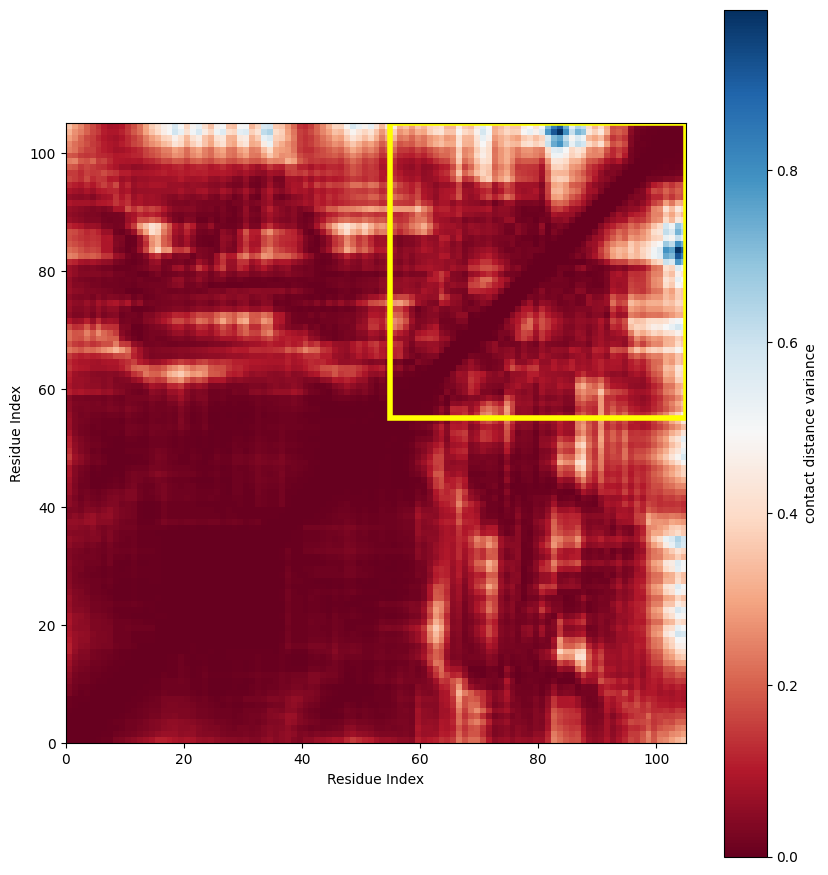

In [10]:
## pool preds
n_iters=2
pool_BSS_preds(jobname,base_output_dir,lambs = lamb_list, model_list=model_list)
pool_enhanced_preds(jobname,base_output_dir,n_iters,model_list,n_coreset = 5)
fsr_identify_res = fsr_identify(jobname,base_output_dir)
fsr_len = fsr_identify_res['fsr_pred_resi'][1] - fsr_identify_res['fsr_pred_resi'][0]
start_res,end_res = extend_interval_symmetric(fsr_identify_res['fsr_pred_resi'][0], fsr_identify_res['fsr_pred_resi'][1], 1, L)

### TMscores to the known conformations
Next, to assess the quality of the set of predicted structures, we compute and plot the TMscore of each prediction relative to the protein's two known conformations.

In [11]:
outputs_SMICE = pd.read_json(f"{base_output_dir}{jobname}/outputs_SMICE.json.zip")

meta_info = metadata_92[metadata_92['jobnames'] == jobname].iloc[0]
ID1 = meta_info['Fold1']
ID2 = meta_info['Fold2']
Seq1 = meta_info['Seq1']
Seq2 = meta_info['Seq2']
ID1_dir = pdb_struc_path+ID1[0:4]+"_"+ID1[4]+".pdb"
ID2_dir = pdb_struc_path+ID2[0:4]+"_"+ID2[4]+".pdb"
fsr_seq = meta_info["Sequence of fold-switching region"]
sequence = meta_info['sequences']
fsr_seq_extend = extend_fsr_seq(fsr_seq,sequence,len(fsr_seq))
TMscore12 = compute_fsr_tmscore(ID1_dir, ID2_dir,fsr_seq_extend )

outputs_SMICE["TMscore1"] = [compute_fsr_tmscore(ID1_dir, pdb_file,fsr_seq_extend ) for pdb_file in list(outputs_SMICE['pdb_path'])]
outputs_SMICE["TMscore2"] = [compute_fsr_tmscore(ID2_dir, pdb_file,fsr_seq_extend ) for pdb_file in list(outputs_SMICE['pdb_path'])]
outputs_SMICE['max_TMscore'] = outputs_SMICE.apply(lambda x: max(x['TMscore1'], x['TMscore2']), axis=1)
outputs_SMICE.to_json(f"{base_output_dir}{jobname}/outputs_SMICE.json.zip")


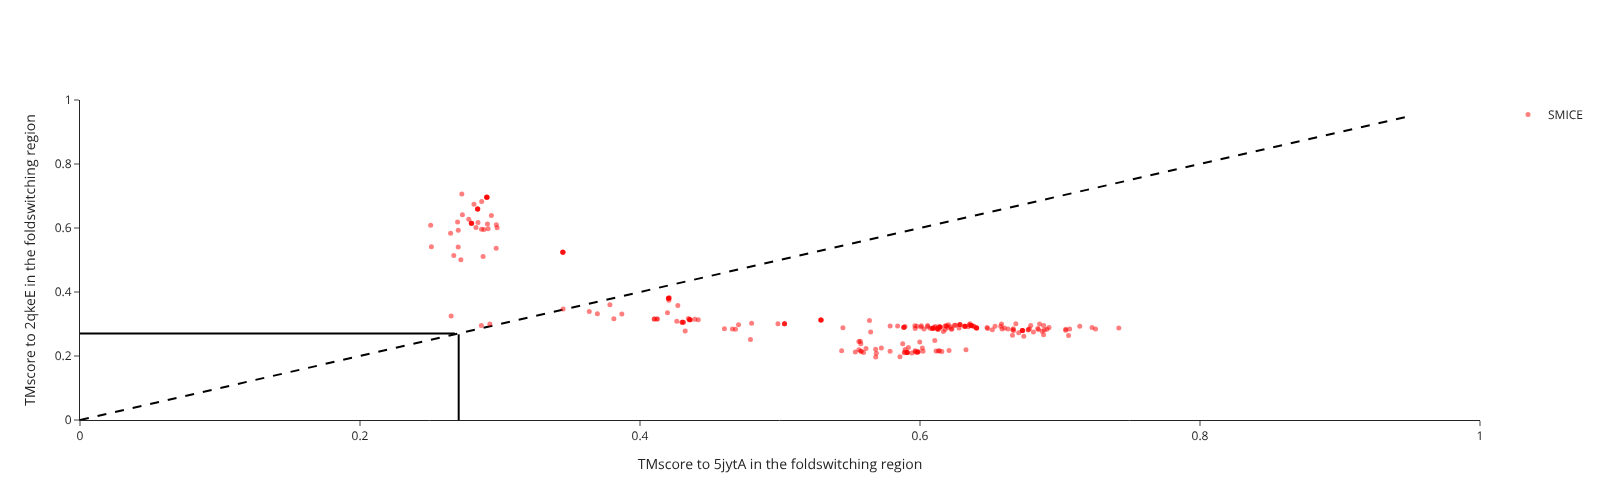

In [15]:
seperate_color = False # whether show the predictions source (from sequential sampling or enhanced sampling)
fig = go.Figure()
fig.update_layout(
template="simple_white",  # Set template to simple_white
width=500,  # Set width of the figure
height=500,  # Set height of the figure
showlegend=True)
fig.add_trace(go.Scatter(
x=np.arange(20)/20, 
y=np.arange(20)/20,
mode='lines',
line=dict(color='black', dash='dash'),  # Customize line color and style
showlegend=False  # Name for the line trace
))
sources = outputs_SMICE["source"].unique()
# Define colors for each source
if seperate_color == True:
    colors = ['#377EB8', '#E41A1C']  # Add more colors if you have more categories
else:
    colors = ['red']
    sources = ['SMICE']
    outputs_SMICE["source"] = "SMICE"

for i, source in enumerate(sources):
    mask = outputs_SMICE["source"] == source
    fig.add_trace(go.Scatter(
        x=outputs_SMICE["TMscore1"][mask], 
        y=outputs_SMICE["TMscore2"][mask],
        mode='markers',
        marker=dict(
            color=colors[i],
            size=5,
            opacity=0.5
        ),
        name=source  # Name includes the source category
    ))
fig.add_trace(go.Scatter(
    x=np.ones(100)*TMscore12, 
    y=np.arange(100)/100*TMscore12,
    mode='lines',
    line=dict(color='black'),  # Customize line color and style
    showlegend=False  # Name for the line trace
))
fig.add_trace(go.Scatter(
    x=np.arange(100)/100*TMscore12, 
    y=np.ones(100)*TMscore12,
    mode='lines',
    line=dict(color='black'),  # Customize line color and style
    showlegend=False  # Name for the line trace
))
fig.update_xaxes(range=[0, 1],title_text='TMscore to %s in the foldswitching region'%ID1)
fig.update_yaxes(range=[0, 1],title_text='TMscore to %s in the foldswitching region'%ID2)
fig.update_xaxes()  # Set x-axis label
fig.show()

### SMICE Representative Extraction Step
Finally, we carry out filtering and clustering to identify a small set of representative structures from the ensemble of predicted structures. For visualization, we plot the PCA embedding of the predictions' contact maps, with the representative structures marked by stars.

In [13]:
## Generate prediction from full MSA as reference
res = ColabFold_batch(f"{MSA_saved_basedir}{jobname}/", f"{MSA_saved_basedir}{jobname}/pdb/",ColabFold_dir, models=model_list)
outputs_full = []
for model in model_list:
    o = {}
    pattern = f"*_relaxed*model_{model:01d}*.pdb"
    pdb_files = glob.glob(os.path.join(f"{MSA_saved_dir}/pdb", pattern))
    score_file_pattern = f"*_model_{model:01d}*.json"
    score_file = glob.glob(os.path.join(f"{MSA_saved_dir}/pdb", score_file_pattern))[0]
    with open(score_file,"r") as f:
        plddt_scores = pd.read_json(f)
    avg_plddt = np.mean(plddt_scores["plddt"])/100
    o.update({'msa_path': f"{MSA_saved_dir}msa.a3m"})
    o.update({'pdb_path': pdb_files[0]})
    o.update({'score_path': score_file})
    o.update({'model': model})
    o.update({'avg_plddt': avg_plddt})
    o.update({'avg_pae': np.mean(np.mean(np.mean(np.array(plddt_scores["pae"]))))})
    o.update({'max_pae': plddt_scores["max_pae"].iloc[0]})
    o.update({'ptm': plddt_scores["ptm"].iloc[0]})
    o.update
    outputs_full.append(o)
outputs_full = pd.DataFrame.from_records(outputs_full)


Timestamp: 2026-01-27 11:27:26
Input directory: ./MSA_cov75_all/5jytA/
Output directory: ./MSA_cov75_all/5jytA/pdb/
ColabFold directory: ./localcolabfold/colabfold-conda/bin
Using specified models: 1
Output directory created/verified: ./MSA_cov75_all/5jytA/pdb/
Running models in order: 1
Starting ColabFold processing...
E0000 00:00:1769531246.979892 3431099 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769531246.987721 3431099 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-27 11:27:29,776 Running colabfold 1.5.5 (00de5b40adeec5368906b9f754ccb4212d05c64d)
2026-01-27 11:27:29,910 Running on GPU
2026-01-27 11:27:30,070 Found 6 citations for tools or databases
2026-01-27 11:27:30,070 Skipping msa (already done)
2026-01-27 11:27:30,070 Done
Processing completed
Total runtime: 0 minutes 4 s


Start Finding Representative Structures
Remaining structures to cluster: 172
Remaining structures to cluster: 159
Remaining structures to cluster: 157
Remaining structures to cluster: 142
Remaining structures to cluster: 140
Remaining structures to cluster: 58
Remaining structures to cluster: 57
Remaining structures to cluster: 55
Remaining structures to cluster: 53
Remaining structures to cluster: 51
Remaining structures to cluster: 50
Remaining structures to cluster: 49
Remaining structures to cluster: 47
Remaining structures to cluster: 32
Remaining structures to cluster: 30
Remaining structures to cluster: 17
Remaining structures to cluster: 11
Remaining structures to cluster: 4
Remaining structures to cluster: 3
finish cluster selection for 5jytA
Successfully created ZIP file: ./outputs_demo/5jytA/RepStructure.zip

9 Representative Structures are found
Drawing PCA Visualization of the Representative Structures


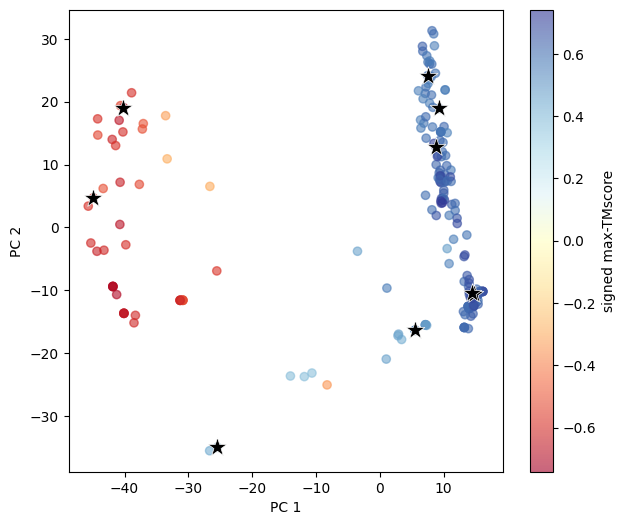

In [14]:
filtered_data = outputs_SMICE[outputs_SMICE['avg_plddt']>0.5]
# PCA_visualization: visualized the selected representative structures with PCA
extract_rep_strucs(jobname,filtered_data,outputs_full,base_output_dir,start_res, end_res,PCA_visualization=True,TMscore_visualize=True)